## **Build a Binary Classification model using UMAP-clustered scaffolds**

### We will use the data obtained in the descriptor generator example, and we'll use cluster groups as cv splits. We have 20 clusters so we will use 5 splits, 4 clusters per group.

In [1]:
import pandas as pd
import numpy as np
from mlchem.ml.feature_selection import filters,wrappers
from mlchem.ml.preprocessing import scaling, undersampling, feature_transformation
from sklearn.model_selection import train_test_split, GroupKFold
from mlchem.metrics import get_geometric_S
from mlchem.helper import  generate_cartesian_product
from sklearn.linear_model import LogisticRegression
#from sklearn.svm import SVC
#from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score#, matthews_corrcoef as mcc
#from itertools import combinations
import joblib


In [2]:
df_desc_rdkit = pd.read_csv('../data/data_rdkit.csv',index_col='SMILES')
data = pd.read_csv('../data/data.csv')
df_desc_rdkit['CLASS'] = data.CLASS.values
cluster_indices = joblib.load('../data/cluster_indices.pkl')
df_desc_rdkit['CLUSTER'] = cluster_indices

C:\Users\Leonardo.Contreas\AppData\Local\Temp\ipykernel_10572\2332006416.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_desc_rdkit['CLASS'] = data.CLASS.values
C:\Users\Leonardo.Contreas\AppData\Local\Temp\ipykernel_10572\2332006416.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_desc_rdkit['CLUSTER'] = cluster_indices


In [3]:
df_desc_rdkit.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,CLASS,CLUSTER
SMILES,,,,,,,,,,,,,,,,,,,,,
CO,7.000000,7.000000,1.000000,1.000000,0.385284,3.000000,32.042,28.010,32.026215,14,...,0,0,0,0,0,0,0,0,0,3
C=NCCC(CCO)CCCCOC(=O)C=O,10.509995,10.509995,0.170950,-0.812254,0.192921,11.823529,243.303,222.135,243.147058,98,...,0,0,0,0,0,0,1,0,0,7
CCC=C=NC#CCC=NCCC(CCO)CCCCOC(=O)C=O,10.666806,10.666806,0.156018,-0.822758,0.138151,11.120000,348.443,320.219,348.204907,138,...,0,0,0,0,0,0,1,0,0,7
C#CCCCCOCCC=C=NC#CCC=NCCC(CCO)CCCCOC(=O)C=O,10.726874,10.726874,0.142995,-0.829415,0.082425,11.000000,444.572,408.284,444.262422,176,...,0,1,0,0,0,0,3,0,0,7
O=CC(=O)OCCCCC(CCO)CCN=CCC#CN=C=CCCOCCCCC1=CCCC=C1,10.757642,10.757642,0.147038,-0.825632,0.065004,13.305556,498.664,456.328,498.309372,198,...,0,0,0,0,0,0,2,0,0,7


## Preprocess data and take care of class imbalance

In [4]:
# Leave 10% out for testing as a holdout set never to interfer with feature selection
# This set will have a representative structural distribution

train_set, test_set, y_train, y_test = train_test_split(
    df_desc_rdkit,
    list(df_desc_rdkit.CLASS.values),
    test_size=0.1,
    stratify=list(df_desc_rdkit.CLUSTER.values),
    random_state=1,
 )

# Logs appear in console output
undersampling.check_class_balance(y_train)
undersampling.check_class_balance(y_test)

2026-10-01 15:39:51,826 - mlchem.ml.preprocessing.undersampling - INFO - CLASS BALANCE [0]: 273 (0.51) [1]: 262 (0.49)
2026-10-01 15:39:51,838 - mlchem.ml.preprocessing.undersampling - INFO - CLASS BALANCE [1]: 33 (0.55) [0]: 27 (0.45)


#### Take care of imbalance if more extreme than 60/40

In [5]:
class_counts = train_set['CLASS'].value_counts()
majority_ratio = class_counts.max() / class_counts.sum()

if majority_ratio > 0.6:   # customise this
    train_set, test_set = undersampling.undersample(
        train_set=train_set,
        test_set=test_set,
        class_column='CLASS',
        desired_proportion_majority=0.6,
        add_dropped_to_test=True,
    )
else:
    print(f'Skipping undersampling: current majority proportion is {majority_ratio:.2%}.')

Skipping undersampling: current majority proportion is 51.03%.


### Add interaction terms to descriptors (degree=1 will change nothing)

In [6]:
train_set

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,CLASS,CLUSTER
SMILES,,,,,,,,,,,,,,,,,,,,,
CBCC(CCCCCC=O)C1CC=N[N+]CCC=CCC(C)C1C#COC(O)=CC,10.606952,10.606952,0.131211,-0.161665,0.129244,23.580645,427.418,387.098,427.312650,170,...,0,0,0,0,0,0,3,0,0,15
CCC(CC=CCCCCCCO)CCC=CCC=CNCN,8.718764,8.718764,0.336649,0.336649,0.220185,13.521739,322.537,284.233,322.298414,134,...,0,0,0,0,0,0,4,0,0,2
C=CCCCC[N+]C(C)CCCONCC=CCC(O)O,8.620495,8.620495,0.243550,-1.273910,0.186762,13.142857,299.435,268.187,299.232919,122,...,0,0,0,0,0,0,2,0,0,4
OCCC1=CCCN(O)CCCCC1,9.401856,9.401856,0.244715,0.244715,0.668015,21.714286,199.294,178.126,199.157229,82,...,0,0,0,0,0,0,0,0,0,3
CC(CCCC=CCCCCCCCCC#CC=CCNCCO)CCCCCCC=CCN,8.654281,8.654281,0.186501,0.186501,0.077552,12.676471,472.802,416.354,472.439264,196,...,0,0,0,0,0,0,12,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CNOCCCCOCC=CN,5.211485,5.211485,0.600580,0.600580,0.413085,11.083333,174.244,156.100,174.136828,72,...,0,0,0,0,0,0,1,0,1,6
B=C(NNCCCCC=C1CC1CCO)C1=C2CCCCCCOCCC1CCC2,8.974914,8.974914,0.326898,0.326898,0.218297,26.733333,414.443,371.099,414.341759,168,...,0,0,0,0,0,0,2,0,0,10
CCOCCC=NCCCNCCC=O,9.989846,9.989846,0.594866,0.594866,0.317635,11.000000,214.309,192.133,214.168128,88,...,0,0,0,0,0,0,0,0,1,4


In [7]:
degree = 1
train_set_poly = feature_transformation.polynomial_expansion(train_set.iloc[:,:-2],degree)
test_set_poly = feature_transformation.polynomial_expansion(test_set.iloc[:,:-2],degree)

train_set_poly['CLASS'] = train_set['CLASS']
test_set_poly['CLASS'] = test_set['CLASS']

In [8]:
train_set_poly

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,CLASS
SMILES,,,,,,,,,,,,,,,,,,,,,
CBCC(CCCCCC=O)C1CC=N[N+]CCC=CCC(C)C1C#COC(O)=CC,10.606952,10.606952,0.131211,-0.161665,0.129244,23.580645,427.418,387.098,427.312650,170.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0
CCC(CC=CCCCCCCO)CCC=CCC=CNCN,8.718764,8.718764,0.336649,0.336649,0.220185,13.521739,322.537,284.233,322.298414,134.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0
C=CCCCC[N+]C(C)CCCONCC=CCC(O)O,8.620495,8.620495,0.243550,-1.273910,0.186762,13.142857,299.435,268.187,299.232919,122.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0
OCCC1=CCCN(O)CCCCC1,9.401856,9.401856,0.244715,0.244715,0.668015,21.714286,199.294,178.126,199.157229,82.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
CC(CCCC=CCCCCCCCCC#CC=CCNCCO)CCCCCCC=CCN,8.654281,8.654281,0.186501,0.186501,0.077552,12.676471,472.802,416.354,472.439264,196.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CNOCCCCOCC=CN,5.211485,5.211485,0.600580,0.600580,0.413085,11.083333,174.244,156.100,174.136828,72.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
B=C(NNCCCCC=C1CC1CCO)C1=C2CCCCCCOCCC1CCC2,8.974914,8.974914,0.326898,0.326898,0.218297,26.733333,414.443,371.099,414.341759,168.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0
CCOCCC=NCCCNCCC=O,9.989846,9.989846,0.594866,0.594866,0.317635,11.000000,214.309,192.133,214.168128,88.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


### Filter and scale data

#### filter

In [9]:
# for tutorial purposes, we set strict thresholds to have a sparser and quicker fitting process

multicollinearity_threshold = 0.6
diversity_threshold = 0.3

print(train_set_poly.shape)
train_set_poly_filter_1 = filters.diversity_filter(df=train_set_poly,
                                                   threshold=diversity_threshold,
                                                   target_variable='CLASS')
print(train_set_poly_filter_1.shape)


train_set_poly_filter_2 = filters.collinearity_filter(df=train_set_poly_filter_1,
                                                      threshold=multicollinearity_threshold,
                                                      target_variable='CLASS',
                                                      method='pearson',
                                                      numeric_only=False)
print(train_set_poly_filter_2.shape)

test_set_poly_filter_2 = test_set_poly[train_set_poly_filter_2.columns]
train_set_poly_filter_2

(535, 205)
(535, 106)
(535, 47)


,MaxAbsEStateIndex,MinEStateIndex,qed,SPS,NumValenceElectrons,NumRadicalElectrons,FpDensityMorgan1,FpDensityMorgan3,BalabanJ,HallKierAlpha,...,NumHDonors,NumSaturatedRings,fr_C_O_noCOO,fr_Imine,fr_NH0,fr_NH2,fr_alkyl_halide,fr_ether,fr_unbrch_alkane,CLASS
SMILES,,,,,,,,,,,,,,,,,,,,,
CBCC(CCCCCC=O)C1CC=N[N+]CCC=CCC(C)C1C#COC(O)=CC,10.606952,-0.161665,0.129244,23.580645,170.0,2.0,1.354839,2.935484,3.101491,-1.995065,...,1.0,0.0,1.0,0.0,2.0,0.0,0.0,1.0,3.0,0
CCC(CC=CCCCCCCO)CCC=CCC=CNCN,8.718764,0.336649,0.220185,13.521739,134.0,0.0,0.956522,2.478261,3.594027,-1.060000,...,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.0,0
C=CCCCC[N+]C(C)CCCONCC=CCC(O)O,8.620495,-1.273910,0.186762,13.142857,122.0,2.0,1.238095,2.761905,3.224423,-0.720000,...,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0
OCCC1=CCCN(O)CCCCC1,9.401856,0.244715,0.668015,21.714286,82.0,0.0,1.214286,2.857143,2.400473,-0.380000,...,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
CC(CCCC=CCCCCCCCCC#CC=CCNCCO)CCCCCCC=CCN,8.654281,0.186501,0.077552,12.676471,196.0,0.0,0.735294,2.029412,3.313399,-1.340000,...,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,12.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CNOCCCCOCC=CN,5.211485,0.600580,0.413085,11.083333,72.0,0.0,1.333333,2.750000,2.813864,-0.580000,...,2.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1
B=C(NNCCCCC=C1CC1CCO)C1=C2CCCCCCOCCC1CCC2,8.974914,0.326898,0.218297,26.733333,168.0,0.0,1.066667,2.833333,1.401280,-0.905065,...,3.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0
CCOCCC=NCCCNCCC=O,9.989846,0.594866,0.317635,11.000000,88.0,0.0,1.333333,2.933333,2.991108,-0.740000,...,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1


In [10]:
(train_set_poly_filter_2.corr()**2)['CLASS'].to_frame().sort_values('CLASS',ascending=False).head()

,CLASS
CLASS,1.000000
MaxAbsEStateIndex,0.343926
MinEStateIndex,0.291383
NumHDonors,0.276041
SMR_VSA1,0.219808


#### scale

In [11]:
train_set_scaled, train_scaler = scaling.scale_df_standard(
    train_set_poly_filter_2,
    columns_to_preserve=['CLASS'], # exclude CLASS from scaling and from returned dataframe
    skip_binary_columns=True,
 )
test_set_scaled = scaling.transform_df(
    test_set_poly_filter_2,
    train_scaler,
    columns_to_preserve=['CLASS'], # exclude CLASS from transformation and from returned dataframe
    skip_binary_columns=True,
 )[0]

y_train = train_set_poly.CLASS.values
y_test = test_set_poly.CLASS.values

In [12]:
train_set_scaled

,MaxAbsEStateIndex,MinEStateIndex,qed,SPS,NumValenceElectrons,NumRadicalElectrons,FpDensityMorgan1,FpDensityMorgan3,BalabanJ,HallKierAlpha,...,NumAtomStereoCenters,NumHDonors,NumSaturatedRings,fr_C_O_noCOO,fr_Imine,fr_NH0,fr_ether,fr_unbrch_alkane,fr_NH2,fr_alkyl_halide
SMILES,,,,,,,,,,,,,,,,,,,,,
CBCC(CCCCCC=O)C1CC=N[N+]CCC=CCC(C)C1C#COC(O)=CC,1.346258,-0.922987,-1.852773,1.423955,2.195880,2.768656,-0.174564,0.831346,0.805546,-2.848635,...,3.958957,-0.117474,-0.310656,2.335898,-0.503411,1.943246,1.155871,0.580823,0.0,0.0
CCC(CC=CCCCCCCO)CCC=CCC=CNCN,0.551503,-0.089574,-1.171257,-0.010486,1.397137,-0.346446,-1.316865,-0.198907,1.681344,-0.996476,...,0.555569,1.877719,-0.310656,-0.380853,-0.503411,-0.695426,-0.519985,0.995144,1.0,0.0
C=CCCCC[N+]C(C)CCCONCC=CCC(O)O,0.510141,-2.783179,-1.421729,-0.064516,1.130889,2.768656,-0.509363,0.440223,1.024136,-0.323010,...,0.555569,1.877719,-0.310656,-0.380853,-0.503411,0.623910,-0.519985,0.166503,0.0,0.0
OCCC1=CCCN(O)CCCCC1,0.839023,-0.243330,2.184795,1.157804,0.243397,-0.346446,-0.577645,0.654822,-0.440961,0.350456,...,-0.578894,0.880122,-0.310656,-0.380853,-0.503411,0.623910,-0.519985,-0.662138,0.0,0.0
CC(CCCC=CCCCCCCCCC#CC=CCNCCO)CCCCCCC=CCN,0.524362,-0.340691,-2.240156,-0.131025,2.772750,-0.346446,-1.951305,-1.210291,1.182349,-1.551094,...,0.555569,1.877719,-0.310656,-0.380853,-0.503411,-0.695426,-0.519985,4.309708,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CNOCCCCOCC=CN,-0.924740,0.351842,0.274341,-0.358212,0.021524,-0.346446,-0.236238,0.413399,0.294106,-0.045701,...,-0.578894,0.880122,-0.310656,-0.380853,-0.503411,-0.695426,1.155871,-0.247818,1.0,0.0
B=C(NNCCCCC=C1CC1CCO)C1=C2CCCCCCOCCC1CCC2,0.659319,-0.105883,-1.185406,1.873541,2.151505,-0.346446,-1.000989,0.601172,-2.217667,-0.689583,...,1.690032,1.877719,2.605146,-0.380853,-0.503411,-0.695426,1.155871,0.166503,0.0,0.0
CCOCCC=NCCCNCCC=O,1.086513,0.342285,-0.440965,-0.370096,0.376521,-0.346446,-0.236238,0.826501,0.609270,-0.362626,...,-0.578894,-0.117474,-0.310656,2.335898,1.506476,0.623910,1.155871,-0.662138,0.0,0.0


In [13]:
groupkfold = GroupKFold(n_splits=5, shuffle=True, random_state=1)
splits = list(groupkfold.split(train_set, train_set['CLASS'], groups=train_set.CLUSTER))

In [14]:
display(len(splits))
splits[0][0].shape, splits[0][1].shape

5

((422,), (113,))

## Modelling - explore wrappers (*Sequential Feature Selection* and *Combinatorial Selection*)

### Sequential Feature Selection

In [15]:
SFS = wrappers.SequentialForwardSelection
estimator = LogisticRegression(l1_ratio=1, C=1, solver='liblinear', random_state=1)
sfs = SFS(
    estimator=estimator,
    estimator_string='Logistic Regression simple model',
    metric=roc_auc_score,
    max_features=20,
    logic='greater',
    task_type='classification',
    cv_indices=splits,
    desired_performance_score='cv',
    log_level='INFO',
)

sfs.fit(
    train_set=train_set_scaled,
    test_set=test_set_scaled,
    y_train=y_train,
    y_test=y_test,
    n_jobs=-1
 )

2026-10-01 15:39:57,622 - mlchem.ml.feature_selection.wrappers - INFO - SFS start: samples=535, features=46, max_features=20, cv_iter=5, n_jobs=12
SFS: 100%|██████████| 20/20 [01:23<00:00,  4.15s/it]
2026-10-01 15:41:20,742 - mlchem.ml.feature_selection.wrappers - INFO - SFS completed: selected_features=20


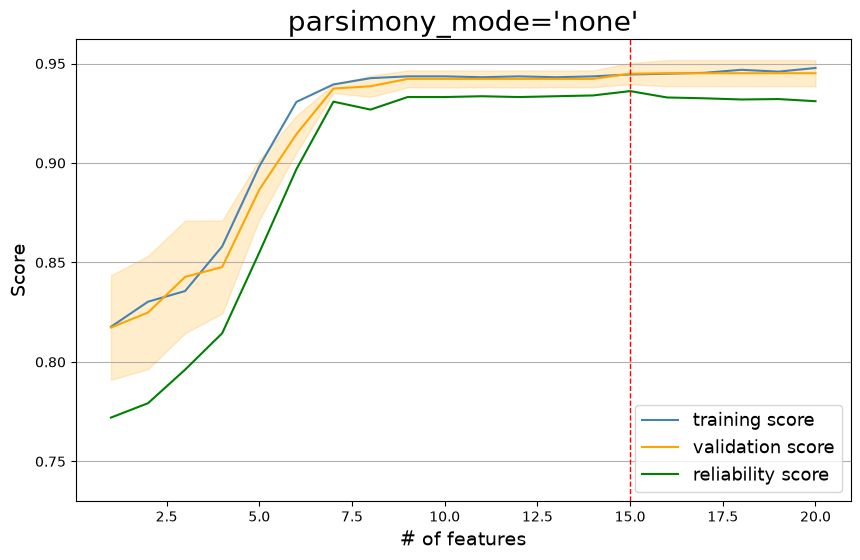

2026-10-01 15:41:21,794 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=15
2026-10-01 15:41:21,845 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['MinEStateIndex', 'HallKierAlpha', 'SMR_VSA1', 'fr_ether', 'VSA_EState2', 'fr_Imine', 'fr_C_O_noCOO', 'fr_alkyl_halide', 'PEOE_VSA7', 'Kappa3', 'PEOE_VSA10', 'SMR_VSA7', 'SlogP_VSA4', 'EState_VSA2', 'SMR_VSA10']
2026-10-01 15:41:21,849 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.945 ± 0.001
2026-10-01 15:41:21,851 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.945 ± 0.005
2026-10-01 15:41:21,852 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.936 ± 0.005


array([0.96648352, 0.93023256, 0.94454545, 0.94117647, 0.94210526])

In [16]:
parsimony_none = sfs.find_best(which=None,
              parsimony_mode='none')
sfs.plot(best_feature=parsimony_none['best_index'], title="parsimony_mode='none'",alphas=[0,0.2,0.])
display(sfs.cv_folds[parsimony_none['best_index']-1])

2026-10-01 15:41:21,892 - mlchem.ml.feature_selection.wrappers - INFO - SFS parsimony: mode=standard_error | reference_k*=15 | selected_k=15


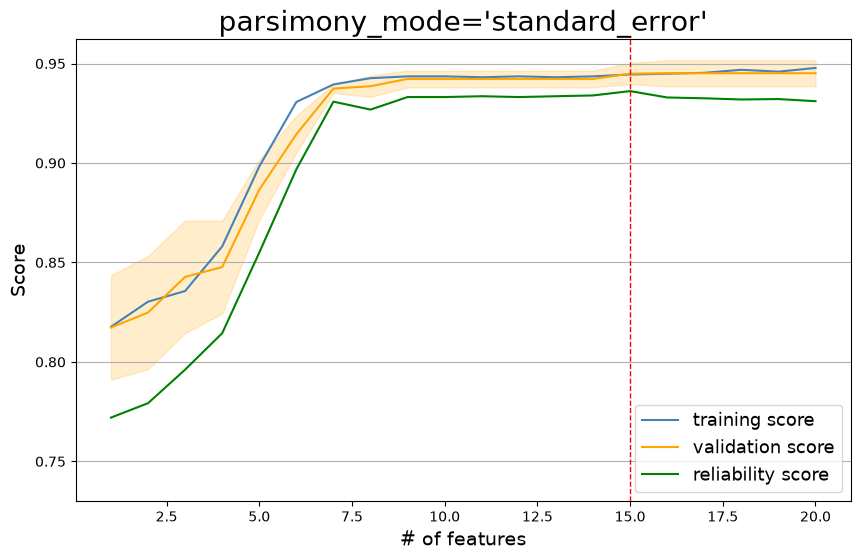

2026-10-01 15:41:22,592 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=15
2026-10-01 15:41:22,593 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['MinEStateIndex', 'HallKierAlpha', 'SMR_VSA1', 'fr_ether', 'VSA_EState2', 'fr_Imine', 'fr_C_O_noCOO', 'fr_alkyl_halide', 'PEOE_VSA7', 'Kappa3', 'PEOE_VSA10', 'SMR_VSA7', 'SlogP_VSA4', 'EState_VSA2', 'SMR_VSA10']
2026-10-01 15:41:22,594 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.945 ± 0.001
2026-10-01 15:41:22,596 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.945 ± 0.005
2026-10-01 15:41:22,598 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.936 ± 0.005


In [17]:
parsimony_standard_error = sfs.find_best(which=None,
              parsimony_mode='standard_error')
sfs.plot(best_feature=parsimony_standard_error['best_index'], title="parsimony_mode='standard_error'",alphas=[0,0.2,0])

In [18]:
# Evaluate parsimony criterion on the smaller candidate feature sets against k*

k_best = 15

for k_candidate in list(range(1, k_best))[::-1]:
    accept = False
    degradation = sfs.cv_folds[k_best-1]-sfs.cv_folds[k_candidate-1]
    degradation_mean = degradation.mean()
    degradation_se = degradation.std()/np.sqrt(5)
    print(f"Mean foldwise degradation between k={k_best} and k={k_candidate}: {degradation_mean:.4f}")
    print(f"SE of degradation between k={k_best} and k={k_candidate}: {degradation_se:.4f}")
    print(f"Is mean degradation smaller than its SE? Accepting ==> {degradation_mean < degradation_se}")
    if degradation_mean < degradation_se:  
        accept = True
        break
    print()
print(f"Accepted k_candidate: {k_candidate}" if accept else "No acceptable k_candidate found.")
    

Mean foldwise degradation between k=15 and k=14: 0.0026
SE of degradation between k=15 and k=14: 0.0015
Is mean degradation smaller than its SE? Accepting ==> False

Mean foldwise degradation between k=15 and k=13: 0.0026
SE of degradation between k=15 and k=13: 0.0015
Is mean degradation smaller than its SE? Accepting ==> False

Mean foldwise degradation between k=15 and k=12: 0.0026
SE of degradation between k=15 and k=12: 0.0015
Is mean degradation smaller than its SE? Accepting ==> False

Mean foldwise degradation between k=15 and k=11: 0.0026
SE of degradation between k=15 and k=11: 0.0015
Is mean degradation smaller than its SE? Accepting ==> False

Mean foldwise degradation between k=15 and k=10: 0.0026
SE of degradation between k=15 and k=10: 0.0015
Is mean degradation smaller than its SE? Accepting ==> False

Mean foldwise degradation between k=15 and k=9: 0.0026
SE of degradation between k=15 and k=9: 0.0015
Is mean degradation smaller than its SE? Accepting ==> False

Mean f

### Combinatorial Selection

In [19]:
COMB = wrappers.CombinatorialSelection
comb = COMB(estimator=estimator,metric=get_geometric_S,logic='greater',
            task_type='classification',cv_indices=splits)

print('COMBINATORIAL STAGE 1 - COARSE SEARCH')
results_1 = comb.fit_stage_1(train_set=train_set_scaled,
                             y_train=y_train,
                             features=train_set_scaled.columns,
                             k=2,
                             training_threshold=0.7,
                             max_subsets=None,
                             ranking_target=y_train,
                             top_ranked_features=15,
                             cv_train_ratio=0.8,
                             cv_iter=None,
                             n_jobs=-1,)
display(results_1.head())
print('COMBINATORIAL STAGE 2 - FINE SEARCH')
results_2 = comb.fit_stage_2(top_n_subsets=5,cv_iter=None,n_jobs=-1)
display(results_2.head())

2026-10-01 15:41:29,781 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 start: samples=535, features=46, k=2, n_jobs=12


COMBINATORIAL STAGE 1 - COARSE SEARCH


Stage 1: 100%|██████████| 120/120 [00:07<00:00, 16.68it/s]
2026-10-01 15:41:37,997 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 completed: kept_subsets=52


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se,Reliability_lower_bound
43,"[MinEStateIndex, qed]",0.819184,0.815832,0.779147,0.002886,0.025426,0.019665,0.759482
16,"[EState_VSA9, MinEStateIndex]",0.819634,0.807554,0.774384,0.008479,0.025231,0.019628,0.754756
40,"[MinEStateIndex, Kappa3]",0.821016,0.807309,0.773059,0.006758,0.026430,0.020481,0.752578
35,"[NumHDonors, MinEStateIndex]",0.820258,0.806101,0.765910,0.011060,0.022541,0.016394,0.749517
42,"[MinEStateIndex, VSA_EState8]",0.817151,0.813506,0.769037,0.007645,0.026126,0.019667,0.749370


2026-10-01 15:41:38,024 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 start: recurrent_features=['EState_VSA9' 'Kappa3' 'MinEStateIndex' 'NumHDonors' 'VSA_EState8' 'qed'], subset_size=5, n_jobs=12


COMBINATORIAL STAGE 2 - FINE SEARCH


Stage 2: 100%|██████████| 62/62 [00:03<00:00, 17.49it/s] 
2026-10-01 15:41:41,756 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 completed: kept_subsets=31
2026-10-01 15:41:41,759 - mlchem.ml.feature_selection.wrappers - INFO - # of Features: 5
2026-10-01 15:41:41,762 - mlchem.ml.feature_selection.wrappers - INFO - Best Features: [np.str_('EState_VSA9'), np.str_('Kappa3'), np.str_('MinEStateIndex'), np.str_('VSA_EState8'), np.str_('qed')]
2026-10-01 15:41:41,764 - mlchem.ml.feature_selection.wrappers - INFO - Train Score: 0.846± 0.004
2026-10-01 15:41:41,769 - mlchem.ml.feature_selection.wrappers - INFO - CV Score: 0.825± 0.028
2026-10-01 15:41:41,774 - mlchem.ml.feature_selection.wrappers - INFO - Reliability Score: 0.788± 0.020


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se,Reliability_lower_bound
26,"[EState_VSA9, Kappa3, MinEStateIndex, VSA_ESta...",0.846413,0.824975,0.787901,0.004155,0.028334,0.019924,0.767977
28,"[EState_VSA9, MinEStateIndex, NumHDonors, VSA_...",0.843030,0.826334,0.782950,0.005800,0.027200,0.020263,0.762687
12,"[Kappa3, MinEStateIndex, qed]",0.826649,0.807342,0.781044,0.002865,0.024565,0.020178,0.760866
25,"[Kappa3, MinEStateIndex, NumHDonors, qed]",0.838398,0.817903,0.780305,0.006453,0.025414,0.020217,0.760088
27,"[EState_VSA9, Kappa3, MinEStateIndex, NumHDono...",0.843243,0.818957,0.783769,0.003802,0.028903,0.023982,0.759787


## **Modelling** - try a different learning algorithm *and* different hyperparameter combinations

### For both SFS and COMB, automatically save best model and associated features

In [20]:
joblib.dump(train_set,'../data/train_set_rdkit')
joblib.dump(test_set,'../data/test_set_rdkit')

['../data/test_set_rdkit']

In [22]:
# both methods
cv_iter = 0     # crossvalidation iterations
cv_indices = splits  # crossvalidation split indices have the priority over cv_iter, cv_splitter and groups
n_jobs=-1

# sfs parameters
max_features = 10    # max features to include in sequential forward selection

# combinatorial selection parameters
top_ranked_features = 10     # number of top ranked features to consider in combinatorial selection.
                             # Ranking is computed based on mutual information with the target variable minus a penalty for correlation with other features.
                             # This is done to promote diversity in the selected features.
training_threshold = 0.75    # minimum accepted training score for a model to be considered valid in combinatorial selection further stages
cv_train_ratio = 0.85     # maximum tolerated ratio between training and test scores for a model to be considered valid in combinatorial selection
top_n_subsets = 5     # number of top ranked subsets to consider in combinatorial selection
k = 3     # number of features to include in each subset for combinatorial selection



### K Nearest Neighbours

2026-10-01 15:51:14,756 - mlchem.ml.feature_selection.wrappers - INFO - SFS start: samples=535, features=46, max_features=10, cv_iter=0, n_jobs=1



KNN_3




SFS: 100%|██████████| 10/10 [00:49<00:00,  4.99s/it]
2026-10-01 15:52:04,641 - mlchem.ml.feature_selection.wrappers - INFO - SFS completed: selected_features=10
2026-10-01 15:52:04,643 - mlchem.ml.feature_selection.wrappers - INFO - SFS parsimony: mode=uncertainty | reference_k*=3 | selected_k=3


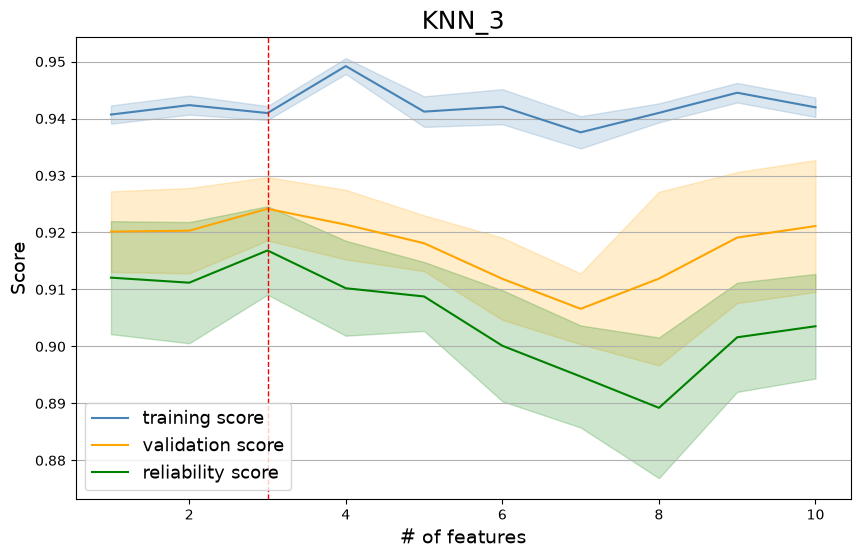

2026-10-01 15:52:05,016 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=3
2026-10-01 15:52:05,017 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['SMR_VSA1', 'EState_VSA10', 'fr_alkyl_halide']
2026-10-01 15:52:05,018 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.941 ± 0.001
2026-10-01 15:52:05,020 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.924 ± 0.006
2026-10-01 15:52:05,021 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.917 ± 0.008
2026-10-01 15:52:05,025 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 start: samples=535, features=46, k=3, n_jobs=12






-------------




COMBINATORIAL STAGE 1 - COARSE SEARCH


Stage 1: 100%|██████████| 175/175 [00:35<00:00,  4.98it/s]
2026-10-01 15:52:40,714 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 completed: kept_subsets=172


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se,Reliability_lower_bound
76,"[SMR_VSA1, NumHDonors, EState_VSA2]",0.947891,0.922621,0.912409,0.001393,0.005381,0.007495,0.904914
12,"[SMR_VSA1, NumHDonors]",0.943266,0.917648,0.907310,0.002609,0.002637,0.004280,0.903030
1,[SMR_VSA1],0.940701,0.920153,0.912070,0.001606,0.007067,0.009920,0.902150
147,"[MaxAbsEStateIndex, NumHDonors, qed]",0.934938,0.908771,0.898823,0.002090,0.007719,0.010913,0.887911
137,"[MaxAbsEStateIndex, TPSA, NumHDonors]",0.936025,0.902262,0.889360,0.003352,0.005084,0.007339,0.882021


2026-10-01 15:52:40,826 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 start: recurrent_features=['EState_VSA2' 'MaxAbsEStateIndex' 'NumHDonors' 'SMR_VSA1' 'TPSA' 'qed'], subset_size=5, n_jobs=12


...

Stage 2: 100%|██████████| 62/62 [00:07<00:00,  8.01it/s]
2026-10-01 15:52:49,204 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 completed: kept_subsets=13
2026-10-01 15:52:49,207 - mlchem.ml.feature_selection.wrappers - INFO - # of Features: 3
2026-10-01 15:52:49,211 - mlchem.ml.feature_selection.wrappers - INFO - Best Features: [np.str_('EState_VSA2'), np.str_('NumHDonors'), np.str_('SMR_VSA1')]
2026-10-01 15:52:49,215 - mlchem.ml.feature_selection.wrappers - INFO - Train Score: 0.948± 0.001
2026-10-01 15:52:49,217 - mlchem.ml.feature_selection.wrappers - INFO - CV Score: 0.923± 0.005
2026-10-01 15:52:49,219 - mlchem.ml.feature_selection.wrappers - INFO - Reliability Score: 0.912± 0.007


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se,Reliability_lower_bound
7,"[EState_VSA2, NumHDonors, SMR_VSA1]",0.947891,0.922621,0.912409,0.001393,0.005381,0.007495,0.904914
2,"[NumHDonors, SMR_VSA1]",0.943266,0.917648,0.907310,0.002609,0.002637,0.004280,0.903030
1,[SMR_VSA1],0.940701,0.920153,0.912070,0.001606,0.007067,0.009920,0.902150
8,"[MaxAbsEStateIndex, NumHDonors, qed]",0.934938,0.908771,0.898823,0.002090,0.007719,0.010913,0.887911
12,"[EState_VSA2, MaxAbsEStateIndex, NumHDonors, S...",0.935513,0.903267,0.890768,0.001250,0.003802,0.005149,0.885619


2026-10-01 15:52:49,411 - mlchem.ml.feature_selection.wrappers - INFO - SFS start: samples=535, features=46, max_features=10, cv_iter=0, n_jobs=1



KNN_5




SFS: 100%|██████████| 10/10 [01:22<00:00,  8.24s/it]
2026-10-01 15:54:11,838 - mlchem.ml.feature_selection.wrappers - INFO - SFS completed: selected_features=10
2026-10-01 15:54:11,839 - mlchem.ml.feature_selection.wrappers - INFO - SFS parsimony: mode=uncertainty | reference_k*=3 | selected_k=1


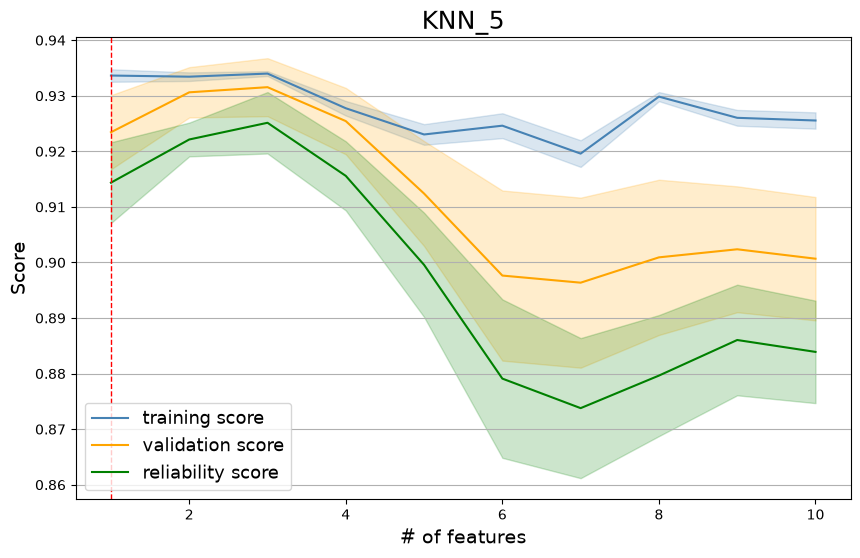

2026-10-01 15:54:12,139 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=1
2026-10-01 15:54:12,140 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['SMR_VSA1']
2026-10-01 15:54:12,141 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.934 ± 0.001
2026-10-01 15:54:12,142 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.923 ± 0.007
2026-10-01 15:54:12,143 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.914 ± 0.007
2026-10-01 15:54:12,146 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 start: samples=535, features=46, k=3, n_jobs=12






-------------




COMBINATORIAL STAGE 1 - COARSE SEARCH


Stage 1: 100%|██████████| 175/175 [00:25<00:00,  6.84it/s]
2026-10-01 15:54:38,144 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 completed: kept_subsets=172


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se,Reliability_lower_bound
2,[SMR_VSA1],0.933641,0.923435,0.914361,0.001123,0.006671,0.007267,0.907094
76,"[SMR_VSA1, NumHDonors, EState_VSA2]",0.931992,0.920111,0.913443,0.002055,0.005665,0.006641,0.906802
15,"[SMR_VSA1, NumHDonors]",0.930518,0.922838,0.909487,0.001733,0.008499,0.006892,0.902595
144,"[MaxAbsEStateIndex, NumHDonors, MinEStateIndex]",0.930450,0.911179,0.898582,0.002509,0.007621,0.006587,0.891994
17,"[SMR_VSA1, EState_VSA2]",0.917552,0.904596,0.896877,0.002508,0.007200,0.008764,0.888113


2026-10-01 15:54:38,164 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 start: recurrent_features=['EState_VSA2' 'MaxAbsEStateIndex' 'MinEStateIndex' 'NumHDonors'
 'SMR_VSA1'], subset_size=5, n_jobs=12


...

Stage 2: 100%|██████████| 31/31 [00:01<00:00, 16.58it/s]
2026-10-01 15:54:40,245 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 completed: kept_subsets=13
2026-10-01 15:54:40,246 - mlchem.ml.feature_selection.wrappers - INFO - # of Features: 1
2026-10-01 15:54:40,247 - mlchem.ml.feature_selection.wrappers - INFO - Best Features: [np.str_('SMR_VSA1')]
2026-10-01 15:54:40,247 - mlchem.ml.feature_selection.wrappers - INFO - Train Score: 0.934± 0.001
2026-10-01 15:54:40,249 - mlchem.ml.feature_selection.wrappers - INFO - CV Score: 0.923± 0.007
2026-10-01 15:54:40,251 - mlchem.ml.feature_selection.wrappers - INFO - Reliability Score: 0.914± 0.007


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se,Reliability_lower_bound
0,[SMR_VSA1],0.933641,0.923435,0.914361,0.001123,0.006671,0.007267,0.907094
5,"[EState_VSA2, NumHDonors, SMR_VSA1]",0.931992,0.920111,0.913443,0.002055,0.005665,0.006641,0.906802
3,"[NumHDonors, SMR_VSA1]",0.930518,0.922838,0.909487,0.001733,0.008499,0.006892,0.902595
8,"[MaxAbsEStateIndex, MinEStateIndex, NumHDonors]",0.930450,0.911179,0.898582,0.002509,0.007621,0.006587,0.891994
4,"[EState_VSA2, SMR_VSA1]",0.917552,0.904596,0.896877,0.002508,0.007200,0.008764,0.888113


2026-10-01 15:54:40,299 - mlchem.ml.feature_selection.wrappers - INFO - SFS start: samples=535, features=46, max_features=10, cv_iter=0, n_jobs=1



KNN_7




SFS: 100%|██████████| 10/10 [00:49<00:00,  4.90s/it]
2026-10-01 15:55:29,314 - mlchem.ml.feature_selection.wrappers - INFO - SFS completed: selected_features=10
2026-10-01 15:55:29,315 - mlchem.ml.feature_selection.wrappers - INFO - SFS parsimony: mode=uncertainty | reference_k*=2 | selected_k=1


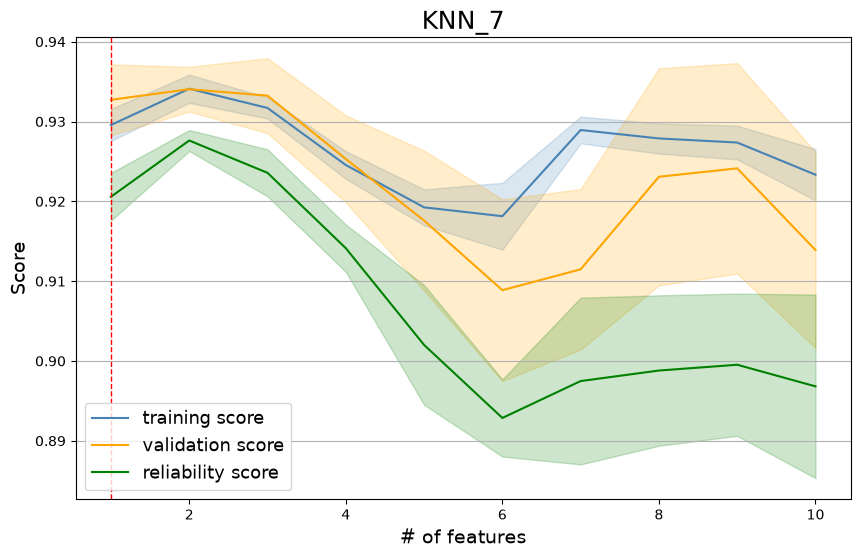

2026-10-01 15:55:29,649 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=1
2026-10-01 15:55:29,651 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['SMR_VSA1']
2026-10-01 15:55:29,652 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.930 ± 0.002
2026-10-01 15:55:29,653 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.933 ± 0.004
2026-10-01 15:55:29,654 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.921 ± 0.003
2026-10-01 15:55:29,658 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 start: samples=535, features=46, k=3, n_jobs=12






-------------




COMBINATORIAL STAGE 1 - COARSE SEARCH


Stage 1: 100%|██████████| 175/175 [00:29<00:00,  5.84it/s]
2026-10-01 15:55:59,991 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 completed: kept_subsets=172


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se,Reliability_lower_bound
1,[SMR_VSA1],0.929568,0.932716,0.920575,0.002005,0.004436,0.002988,0.917587
141,"[MaxAbsEStateIndex, NumHDonors, MinEStateIndex]",0.930686,0.919925,0.902199,0.001278,0.010364,0.006913,0.895286
17,"[SMR_VSA1, NumHDonors]",0.926761,0.915514,0.901930,0.001762,0.008489,0.007196,0.894734
13,"[SMR_VSA1, EState_VSA2]",0.909307,0.903732,0.894548,0.002650,0.005232,0.005641,0.888907
144,"[MaxAbsEStateIndex, NumHDonors, qed]",0.921268,0.910858,0.895938,0.001582,0.009969,0.009701,0.886238


2026-10-01 15:56:00,013 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 start: recurrent_features=['EState_VSA2' 'MaxAbsEStateIndex' 'MinEStateIndex' 'NumHDonors'
 'SMR_VSA1' 'qed'], subset_size=5, n_jobs=12


...

Stage 2: 100%|██████████| 62/62 [00:05<00:00, 12.40it/s]
2026-10-01 15:56:05,273 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 completed: kept_subsets=22
2026-10-01 15:56:05,275 - mlchem.ml.feature_selection.wrappers - INFO - # of Features: 1
2026-10-01 15:56:05,278 - mlchem.ml.feature_selection.wrappers - INFO - Best Features: [np.str_('SMR_VSA1')]
2026-10-01 15:56:05,283 - mlchem.ml.feature_selection.wrappers - INFO - Train Score: 0.930± 0.002
2026-10-01 15:56:05,286 - mlchem.ml.feature_selection.wrappers - INFO - CV Score: 0.933± 0.004
2026-10-01 15:56:05,288 - mlchem.ml.feature_selection.wrappers - INFO - Reliability Score: 0.921± 0.003


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se,Reliability_lower_bound
0,[SMR_VSA1],0.929568,0.932716,0.920575,0.002005,0.004436,0.002988,0.917587
8,"[MaxAbsEStateIndex, MinEStateIndex, NumHDonors]",0.930686,0.919925,0.902199,0.001278,0.010364,0.006913,0.895286
3,"[NumHDonors, SMR_VSA1]",0.926761,0.915514,0.901930,0.001762,0.008489,0.007196,0.894734
18,"[MaxAbsEStateIndex, NumHDonors, SMR_VSA1, qed]",0.915407,0.908229,0.896366,0.001796,0.008460,0.005699,0.890667
10,"[MaxAbsEStateIndex, NumHDonors, qed]",0.921268,0.910858,0.895938,0.001582,0.009969,0.009701,0.886238


2026-10-01 15:56:05,367 - mlchem.ml.feature_selection.wrappers - INFO - SFS start: samples=535, features=46, max_features=10, cv_iter=0, n_jobs=1



KNN_9




SFS: 100%|██████████| 10/10 [01:52<00:00, 11.20s/it]
2026-10-01 15:57:57,411 - mlchem.ml.feature_selection.wrappers - INFO - SFS completed: selected_features=10
2026-10-01 15:57:57,414 - mlchem.ml.feature_selection.wrappers - INFO - SFS parsimony: mode=uncertainty | reference_k*=2 | selected_k=2


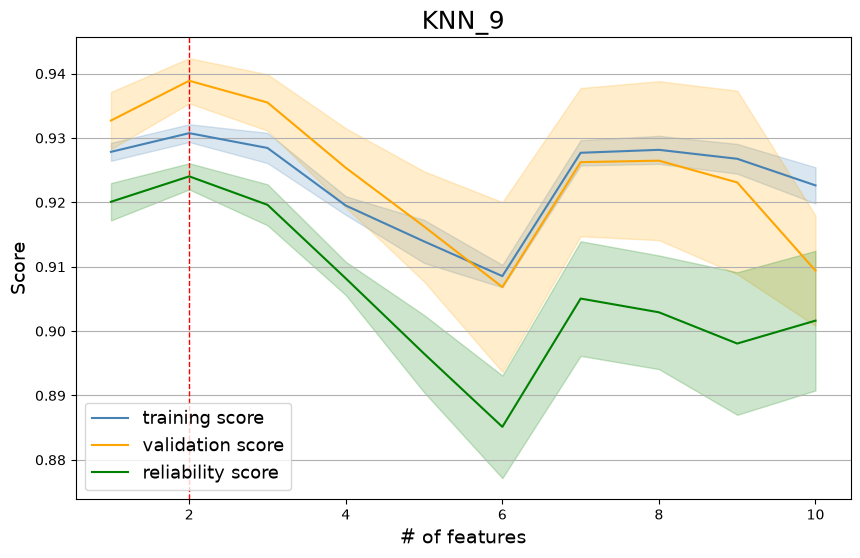

2026-10-01 15:57:57,927 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=2
2026-10-01 15:57:57,930 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['SMR_VSA1', 'fr_alkyl_halide']
2026-10-01 15:57:57,935 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.931 ± 0.001
2026-10-01 15:57:57,938 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.939 ± 0.004
2026-10-01 15:57:57,942 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.924 ± 0.002
2026-10-01 15:57:57,949 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 start: samples=535, features=46, k=3, n_jobs=12






-------------




COMBINATORIAL STAGE 1 - COARSE SEARCH


Stage 1: 100%|██████████| 175/175 [00:38<00:00,  4.57it/s]
2026-10-01 15:58:37,002 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 completed: kept_subsets=172


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se,Reliability_lower_bound
4,[SMR_VSA1],0.927849,0.932716,0.920093,0.001396,0.004436,0.002908,0.917185
12,"[SMR_VSA1, NumHDonors]",0.920034,0.909699,0.903041,0.002424,0.003325,0.003738,0.899303
15,"[SMR_VSA1, EState_VSA2]",0.909990,0.907573,0.897044,0.000541,0.006659,0.005632,0.891412
142,"[MaxAbsEStateIndex, NumHDonors, MinEStateIndex]",0.924802,0.914789,0.897497,0.001557,0.012373,0.010800,0.886697
33,"[MaxAbsEStateIndex, NumHDonors]",0.920723,0.905225,0.887743,0.001874,0.011867,0.008959,0.878784


2026-10-01 15:58:37,043 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 start: recurrent_features=['EState_VSA2' 'MaxAbsEStateIndex' 'MinEStateIndex' 'NumHDonors'
 'SMR_VSA1'], subset_size=5, n_jobs=12


COMBINATORIAL STAGE 2 - FINE SEARCH


Stage 2: 100%|██████████| 31/31 [00:05<00:00,  5.71it/s]
2026-10-01 15:58:42,737 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 completed: kept_subsets=10
2026-10-01 15:58:42,758 - mlchem.ml.feature_selection.wrappers - INFO - # of Features: 1
2026-10-01 15:58:42,769 - mlchem.ml.feature_selection.wrappers - INFO - Best Features: [np.str_('SMR_VSA1')]
2026-10-01 15:58:42,775 - mlchem.ml.feature_selection.wrappers - INFO - Train Score: 0.928± 0.001
2026-10-01 15:58:42,780 - mlchem.ml.feature_selection.wrappers - INFO - CV Score: 0.933± 0.004
2026-10-01 15:58:42,783 - mlchem.ml.feature_selection.wrappers - INFO - Reliability Score: 0.920± 0.003


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se,Reliability_lower_bound
0,[SMR_VSA1],0.927849,0.932716,0.920093,0.001396,0.004436,0.002908,0.917185
6,"[NumHDonors, SMR_VSA1]",0.920034,0.909699,0.903041,0.002424,0.003325,0.003738,0.899303
8,"[MaxAbsEStateIndex, MinEStateIndex, NumHDonors]",0.924802,0.914789,0.897497,0.001557,0.012373,0.010800,0.886697
5,"[EState_VSA2, MaxAbsEStateIndex, MinEStateInde...",0.915300,0.911061,0.895010,0.002885,0.010748,0.009189,0.885822
1,"[MaxAbsEStateIndex, NumHDonors]",0.920723,0.905225,0.887743,0.001874,0.011867,0.008959,0.878784


In [ ]:
SFS = wrappers.SequentialForwardSelection
metric = roc_auc_score

neighbours = [3, 5, 7, 9]

for n in neighbours:
    estimator = KNeighborsClassifier(n_neighbors=n)
    estimator_string = f'KNN_{n}'
    print('\n%s\n\n' % estimator_string)
    sfs = SFS(
        estimator=estimator,
        estimator_string=estimator_string,
        metric=metric,
        max_features=max_features,
        cv_iter=cv_iter,
        logic='greater',
        task_type='classification',
        log_level='INFO',
        cv_indices=cv_indices,
    )
    # test_set and y_test only useful for debugging purposes if log_level='DEBUG'
    sfs.fit(
        train_set=train_set_scaled,
        test_set=test_set_scaled,
        y_train=y_train,
        y_test=y_test,
    )

    features_best_sfs = sfs.find_best(parsimony_mode='uncertainty')['features']
    sfs.plot(title_size=18, title=estimator_string, best_feature=len(features_best_sfs))
    print('\n\n\n\n-------------\n\n\n\n')

    COMB = wrappers.CombinatorialSelection
    comb = COMB(estimator=estimator,metric=metric,logic='greater',
                task_type='classification',
                cv_indices=cv_indices,
                )

    print('COMBINATORIAL STAGE 1 - COARSE SEARCH')
    results_1 = comb.fit_stage_1(train_set=train_set_scaled,
                                y_train=y_train,
                                features=train_set_scaled.columns,
                                k=k,
                                training_threshold=training_threshold,
                                max_subsets=None,
                                ranking_target=y_train,
                                top_ranked_features=top_ranked_features,
                                cv_train_ratio=cv_train_ratio,
                                cv_iter=cv_iter,
                                n_jobs=n_jobs,)
    display(results_1.head())
    print('COMBINATORIAL STAGE 2 - FINE SEARCH')
    results_2 = comb.fit_stage_2(top_n_subsets=top_n_subsets,cv_iter=cv_iter,n_jobs=n_jobs)
    display(results_2.head())

   
    fitted_estimator_sfs = estimator.fit(train_set_scaled[features_best_sfs], y_train)
    joblib.dump(fitted_estimator_sfs, f'../data/{estimator_string}_SFS_estimator')
    joblib.dump(features_best_sfs, f'../data/{estimator_string}_SFS_cols')

    if results_2.empty:
        # No subset survived the stage-2 cv_train_ratio/training_threshold filters for this estimator
        print(f'No combinatorial subsets passed the stage-2 filters for {estimator_string}; skipping COMB save.')
    else:
        features_best_comb = results_2['feature_subsets'].values[0]
        fitted_estimator_comb = estimator.fit(train_set_scaled[features_best_comb], y_train)
        joblib.dump(fitted_estimator_comb, f'../data/{estimator_string}_COMB_estimator')
        joblib.dump(features_best_comb, f'../data/{estimator_string}_COMB_cols')

### Logistic Regression

2026-10-01 17:02:50,170 - mlchem.ml.feature_selection.wrappers - INFO - SFS start: samples=535, features=46, max_features=10, cv_iter=0, n_jobs=1



LOGREG_l1ratio_0_C_0.1




SFS: 100%|██████████| 10/10 [00:34<00:00,  3.45s/it]
2026-10-01 17:03:24,692 - mlchem.ml.feature_selection.wrappers - INFO - SFS completed: selected_features=10
2026-10-01 17:03:24,695 - mlchem.ml.feature_selection.wrappers - INFO - SFS parsimony: mode=uncertainty | reference_k*=10 | selected_k=10


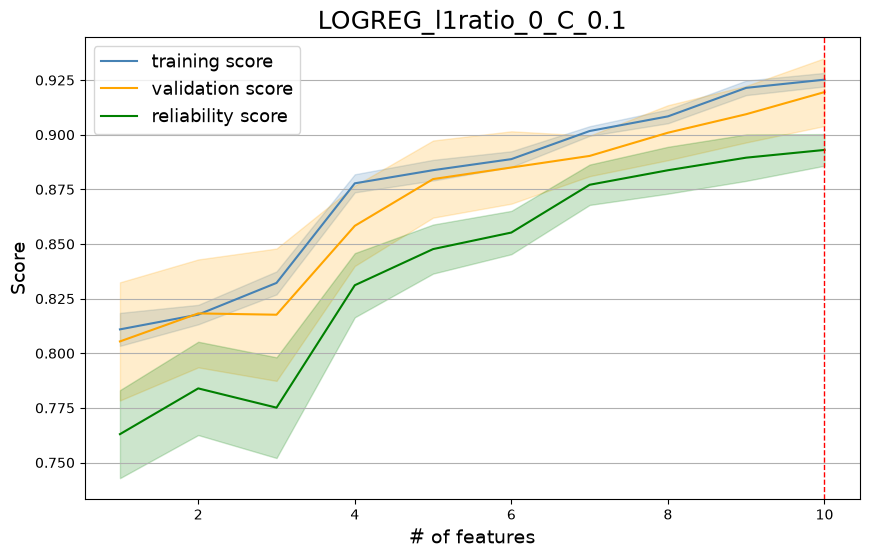

2026-10-01 17:03:25,367 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=10
2026-10-01 17:03:25,368 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['MinEStateIndex', 'VSA_EState5', 'fr_C_O_noCOO', 'MaxAbsEStateIndex', 'SMR_VSA10', 'SMR_VSA1', 'fr_ether', 'fr_Imine', 'VSA_EState2', 'NumHDonors']
2026-10-01 17:03:25,372 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.925 ± 0.003
2026-10-01 17:03:25,375 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.920 ± 0.016
2026-10-01 17:03:25,378 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.893 ± 0.007
2026-10-01 17:03:25,385 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 start: samples=535, features=46, k=3, n_jobs=12






-------------




COMBINATORIAL STAGE 1 - COARSE SEARCH


Stage 1: 100%|██████████| 175/175 [00:16<00:00, 10.80it/s]
2026-10-01 17:03:42,322 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 completed: kept_subsets=117


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se,Reliability_lower_bound
90,"[MaxAbsEStateIndex, NumHDonors, MinEStateIndex]",0.865695,0.840870,0.807556,0.004530,0.025657,0.017273,0.790283
71,"[EState_VSA9, MaxAbsEStateIndex, NumHDonors]",0.851795,0.818977,0.793953,0.008489,0.025565,0.026476,0.767477
92,"[MaxAbsEStateIndex, NumHDonors, qed]",0.868580,0.830420,0.806376,0.007243,0.038755,0.040015,0.766361
36,"[SMR_VSA1, MaxAbsEStateIndex, NumHDonors]",0.842847,0.817314,0.795426,0.008739,0.027120,0.029221,0.766205
91,"[MaxAbsEStateIndex, NumHDonors, EState_VSA2]",0.835089,0.808515,0.768915,0.011261,0.022102,0.009906,0.759008


2026-10-01 17:03:42,344 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 start: recurrent_features=['EState_VSA2' 'EState_VSA9' 'MaxAbsEStateIndex' 'MinEStateIndex'
 'NumHDonors' 'SMR_VSA1' 'qed'], subset_size=5, n_jobs=12


...

Stage 2: 100%|██████████| 119/119 [00:04<00:00, 25.23it/s]
2026-10-01 17:03:47,256 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 completed: kept_subsets=30
2026-10-01 17:03:47,259 - mlchem.ml.feature_selection.wrappers - INFO - # of Features: 4
2026-10-01 17:03:47,263 - mlchem.ml.feature_selection.wrappers - INFO - Best Features: [np.str_('EState_VSA9'), np.str_('MaxAbsEStateIndex'), np.str_('NumHDonors'), np.str_('qed')]
2026-10-01 17:03:47,267 - mlchem.ml.feature_selection.wrappers - INFO - Train Score: 0.863± 0.004
2026-10-01 17:03:47,270 - mlchem.ml.feature_selection.wrappers - INFO - CV Score: 0.849± 0.015
2026-10-01 17:03:47,274 - mlchem.ml.feature_selection.wrappers - INFO - Reliability Score: 0.828± 0.013


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se,Reliability_lower_bound
13,"[EState_VSA9, MaxAbsEStateIndex, NumHDonors, qed]",0.863130,0.849323,0.828092,0.004092,0.014906,0.013298,0.814794
10,"[EState_VSA2, MaxAbsEStateIndex, NumHDonors, qed]",0.866512,0.849784,0.819854,0.006234,0.021991,0.019552,0.800302
26,"[EState_VSA9, MaxAbsEStateIndex, NumHDonors, S...",0.857084,0.841911,0.815875,0.004520,0.018231,0.015652,0.800223
18,"[MaxAbsEStateIndex, NumHDonors, SMR_VSA1, qed]",0.853691,0.847582,0.813375,0.004625,0.019432,0.013436,0.799939
20,"[EState_VSA2, EState_VSA9, MaxAbsEStateIndex, ...",0.859337,0.838644,0.812203,0.005698,0.018537,0.016083,0.796119


2026-10-01 17:03:47,367 - mlchem.ml.feature_selection.wrappers - INFO - SFS start: samples=535, features=46, max_features=10, cv_iter=0, n_jobs=1



LOGREG_l1ratio_0_C_1.0




SFS: 100%|██████████| 10/10 [00:47<00:00,  4.74s/it]
2026-10-01 17:04:34,823 - mlchem.ml.feature_selection.wrappers - INFO - SFS completed: selected_features=10
2026-10-01 17:04:34,828 - mlchem.ml.feature_selection.wrappers - INFO - SFS parsimony: mode=uncertainty | reference_k*=6 | selected_k=6


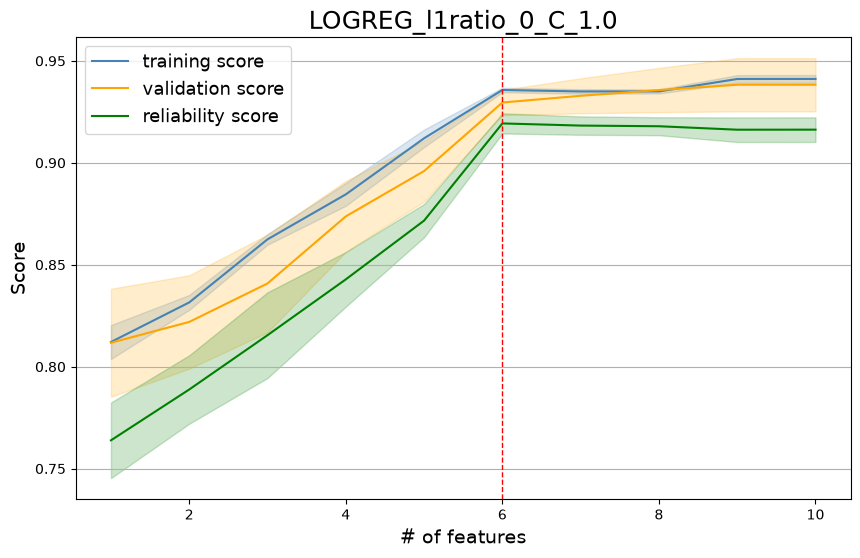

2026-10-01 17:04:35,736 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=6
2026-10-01 17:04:35,738 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['MinEStateIndex', 'VSA_EState2', 'MaxAbsEStateIndex', 'SMR_VSA1', 'fr_ether', 'fr_Imine']
2026-10-01 17:04:35,742 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.936 ± 0.001
2026-10-01 17:04:35,744 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.930 ± 0.006
2026-10-01 17:04:35,746 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.919 ± 0.005
2026-10-01 17:04:35,757 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 start: samples=535, features=46, k=3, n_jobs=12






-------------




COMBINATORIAL STAGE 1 - COARSE SEARCH


Stage 1: 100%|██████████| 175/175 [00:21<00:00,  8.32it/s]
2026-10-01 17:04:57,935 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 completed: kept_subsets=122


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se,Reliability_lower_bound
100,"[MaxAbsEStateIndex, NumHDonors, qed]",0.866700,0.842676,0.815111,0.003039,0.029524,0.029182,0.785929
105,"[TPSA, NumHDonors, MinEStateIndex]",0.842400,0.823756,0.800145,0.007425,0.016733,0.015433,0.784712
96,"[MaxAbsEStateIndex, NumHDonors, MinEStateIndex]",0.865292,0.836004,0.802428,0.004040,0.024371,0.018128,0.784300
77,"[EState_VSA9, MaxAbsEStateIndex, NumHDonors]",0.849089,0.813084,0.801819,0.009162,0.027987,0.031063,0.770756
98,"[MaxAbsEStateIndex, NumHDonors, PEOE_VSA8]",0.858071,0.831377,0.794250,0.007528,0.035252,0.032886,0.761364


2026-10-01 17:04:57,979 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 start: recurrent_features=['EState_VSA9' 'MaxAbsEStateIndex' 'MinEStateIndex' 'NumHDonors'
 'PEOE_VSA8' 'TPSA' 'qed'], subset_size=5, n_jobs=12


...

Stage 2: 100%|██████████| 119/119 [00:06<00:00, 18.06it/s]
2026-10-01 17:05:04,804 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 completed: kept_subsets=31
2026-10-01 17:05:04,807 - mlchem.ml.feature_selection.wrappers - INFO - # of Features: 5
2026-10-01 17:05:04,811 - mlchem.ml.feature_selection.wrappers - INFO - Best Features: [np.str_('EState_VSA9'), np.str_('MaxAbsEStateIndex'), np.str_('NumHDonors'), np.str_('PEOE_VSA8'), np.str_('qed')]
2026-10-01 17:05:04,814 - mlchem.ml.feature_selection.wrappers - INFO - Train Score: 0.865± 0.002
2026-10-01 17:05:04,817 - mlchem.ml.feature_selection.wrappers - INFO - CV Score: 0.847± 0.014
2026-10-01 17:05:04,820 - mlchem.ml.feature_selection.wrappers - INFO - Reliability Score: 0.833± 0.015


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se,Reliability_lower_bound
22,"[EState_VSA9, MaxAbsEStateIndex, NumHDonors, P...",0.864948,0.847240,0.832792,0.001978,0.014027,0.014697,0.818095
10,"[EState_VSA9, MaxAbsEStateIndex, NumHDonors, qed]",0.860842,0.846294,0.827627,0.004259,0.013113,0.011668,0.815959
28,"[MaxAbsEStateIndex, MinEStateIndex, NumHDonors...",0.875992,0.845249,0.826348,0.002287,0.020742,0.021030,0.805319
29,"[MaxAbsEStateIndex, MinEStateIndex, NumHDonors...",0.870543,0.845328,0.818011,0.002729,0.019827,0.015324,0.802687
9,"[EState_VSA9, MaxAbsEStateIndex, NumHDonors, P...",0.857488,0.838985,0.818191,0.008707,0.015808,0.017504,0.800687


2026-10-01 17:05:04,918 - mlchem.ml.feature_selection.wrappers - INFO - SFS start: samples=535, features=46, max_features=10, cv_iter=0, n_jobs=1



LOGREG_l1ratio_0_C_10.0




SFS: 100%|██████████| 10/10 [00:33<00:00,  3.35s/it]
2026-10-01 17:05:38,414 - mlchem.ml.feature_selection.wrappers - INFO - SFS completed: selected_features=10
2026-10-01 17:05:38,417 - mlchem.ml.feature_selection.wrappers - INFO - SFS parsimony: mode=uncertainty | reference_k*=9 | selected_k=9


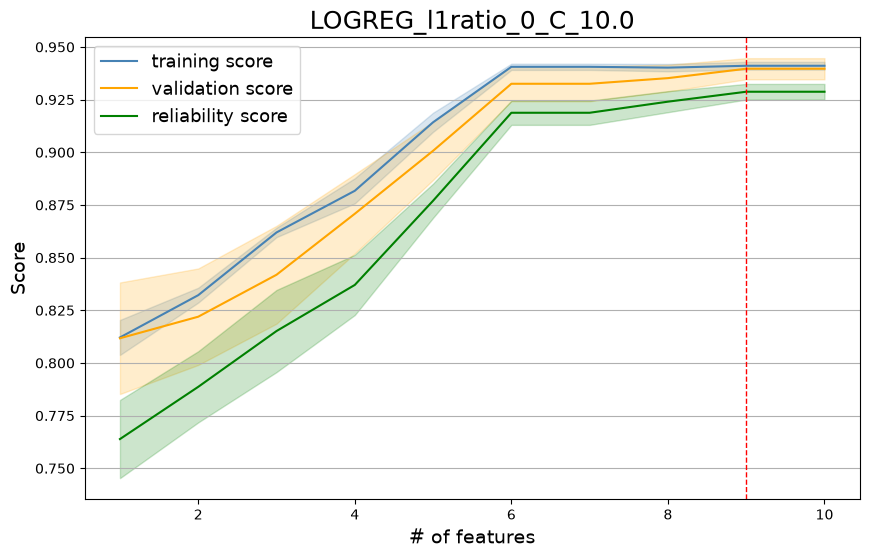

2026-10-01 17:05:38,958 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=9
2026-10-01 17:05:38,958 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['MinEStateIndex', 'VSA_EState2', 'MaxAbsEStateIndex', 'SMR_VSA1', 'fr_ether', 'fr_Imine', 'NumValenceElectrons', 'fr_C_O_noCOO', 'FpDensityMorgan3']
2026-10-01 17:05:38,963 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.941 ± 0.002
2026-10-01 17:05:38,966 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.940 ± 0.005
2026-10-01 17:05:38,968 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.929 ± 0.004
2026-10-01 17:05:38,973 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 start: samples=535, features=46, k=3, n_jobs=12






-------------




COMBINATORIAL STAGE 1 - COARSE SEARCH


Stage 1: 100%|██████████| 175/175 [00:15<00:00, 11.60it/s]
2026-10-01 17:05:54,864 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 completed: kept_subsets=122


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se,Reliability_lower_bound
96,"[MaxAbsEStateIndex, NumHDonors, qed]",0.865857,0.845448,0.817587,0.003089,0.027164,0.026512,0.791074
105,"[TPSA, NumHDonors, MinEStateIndex]",0.843895,0.824792,0.803288,0.005674,0.015940,0.014790,0.788498
99,"[MaxAbsEStateIndex, NumHDonors, MinEStateIndex]",0.866352,0.829802,0.798862,0.004771,0.024484,0.020577,0.778285
75,"[EState_VSA9, MaxAbsEStateIndex, NumHDonors]",0.848391,0.815064,0.799598,0.009662,0.028923,0.030620,0.768978
97,"[MaxAbsEStateIndex, NumHDonors, PEOE_VSA8]",0.857105,0.823848,0.795137,0.006717,0.029691,0.029418,0.765719


2026-10-01 17:05:54,902 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 start: recurrent_features=['EState_VSA9' 'MaxAbsEStateIndex' 'MinEStateIndex' 'NumHDonors'
 'PEOE_VSA8' 'TPSA' 'qed'], subset_size=5, n_jobs=12


...

Stage 2: 100%|██████████| 119/119 [00:04<00:00, 24.40it/s]
2026-10-01 17:06:00,036 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 completed: kept_subsets=29
2026-10-01 17:06:00,039 - mlchem.ml.feature_selection.wrappers - INFO - # of Features: 5
2026-10-01 17:06:00,042 - mlchem.ml.feature_selection.wrappers - INFO - Best Features: [np.str_('EState_VSA9'), np.str_('MaxAbsEStateIndex'), np.str_('NumHDonors'), np.str_('PEOE_VSA8'), np.str_('qed')]
2026-10-01 17:06:00,048 - mlchem.ml.feature_selection.wrappers - INFO - Train Score: 0.865± 0.002
2026-10-01 17:06:00,052 - mlchem.ml.feature_selection.wrappers - INFO - CV Score: 0.843± 0.013
2026-10-01 17:06:00,055 - mlchem.ml.feature_selection.wrappers - INFO - Reliability Score: 0.831± 0.014


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se,Reliability_lower_bound
22,"[EState_VSA9, MaxAbsEStateIndex, NumHDonors, P...",0.864707,0.842821,0.830685,0.002314,0.012540,0.014059,0.816626
10,"[EState_VSA9, MaxAbsEStateIndex, NumHDonors, qed]",0.858755,0.840139,0.825413,0.003884,0.012826,0.011845,0.813567
28,"[MaxAbsEStateIndex, MinEStateIndex, NumHDonors...",0.870606,0.847315,0.819684,0.002967,0.018764,0.013591,0.806092
15,"[MaxAbsEStateIndex, NumHDonors, PEOE_VSA8, qed]",0.870074,0.848551,0.829139,0.002958,0.022295,0.023704,0.805435
25,"[MaxAbsEStateIndex, MinEStateIndex, NumHDonors...",0.875705,0.844703,0.823418,0.002679,0.021062,0.019601,0.803818


2026-10-01 17:06:00,143 - mlchem.ml.feature_selection.wrappers - INFO - SFS start: samples=535, features=46, max_features=10, cv_iter=0, n_jobs=1



LOGREG_l1ratio_1_C_0.1




SFS: 100%|██████████| 10/10 [00:26<00:00,  2.67s/it]
2026-10-01 17:06:26,892 - mlchem.ml.feature_selection.wrappers - INFO - SFS completed: selected_features=10
2026-10-01 17:06:26,897 - mlchem.ml.feature_selection.wrappers - INFO - SFS parsimony: mode=uncertainty | reference_k*=6 | selected_k=6


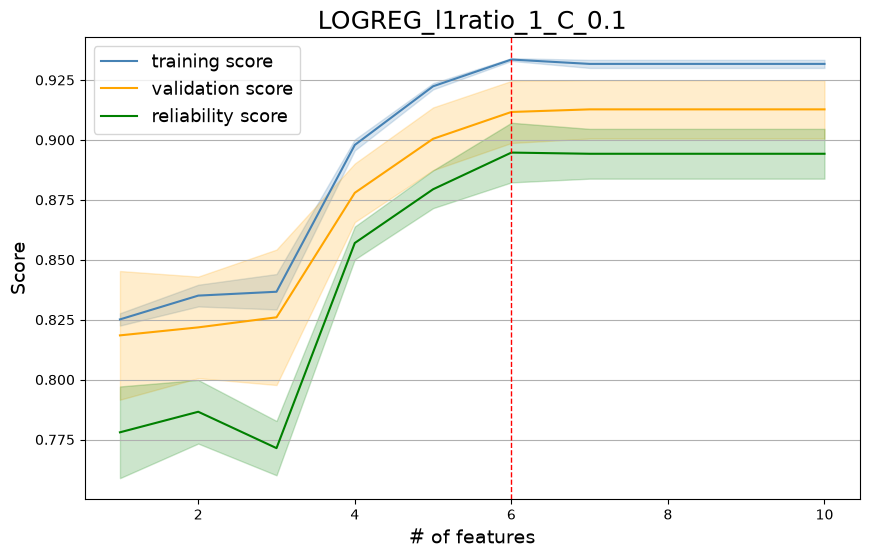

2026-10-01 17:06:27,561 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=6
2026-10-01 17:06:27,563 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['MinEStateIndex', 'VSA_EState2', 'SMR_VSA1', 'fr_ether', 'fr_Imine', 'MaxAbsEStateIndex']
2026-10-01 17:06:27,564 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.934 ± 0.001
2026-10-01 17:06:27,565 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.912 ± 0.013
2026-10-01 17:06:27,568 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.895 ± 0.012
2026-10-01 17:06:27,573 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 start: samples=535, features=46, k=3, n_jobs=12






-------------




COMBINATORIAL STAGE 1 - COARSE SEARCH


Stage 1: 100%|██████████| 175/175 [00:10<00:00, 16.97it/s]
2026-10-01 17:06:38,413 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 completed: kept_subsets=113


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se,Reliability_lower_bound
106,"[NumHDonors, MinEStateIndex, qed]",0.843996,0.824380,0.790149,0.005166,0.024735,0.020194,0.769954
79,"[EState_VSA9, MinEStateIndex, qed]",0.843103,0.823801,0.790536,0.002753,0.028554,0.024323,0.766214
10,"[EState_VSA9, MinEStateIndex]",0.831277,0.818411,0.787723,0.003260,0.026123,0.021785,0.765938
80,"[EState_VSA9, MinEStateIndex, PEOE_VSA8]",0.830833,0.820203,0.787247,0.002971,0.026475,0.021517,0.765730
110,"[MinEStateIndex, PEOE_VSA8, qed]",0.825668,0.823556,0.781462,0.003046,0.026358,0.018754,0.762709


2026-10-01 17:06:38,438 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 start: recurrent_features=['EState_VSA9' 'MinEStateIndex' 'NumHDonors' 'PEOE_VSA8' 'qed'], subset_size=5, n_jobs=12


...

Stage 2: 100%|██████████| 31/31 [00:01<00:00, 23.51it/s] 
2026-10-01 17:06:39,951 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 completed: kept_subsets=14
2026-10-01 17:06:39,953 - mlchem.ml.feature_selection.wrappers - INFO - # of Features: 4
2026-10-01 17:06:39,955 - mlchem.ml.feature_selection.wrappers - INFO - Best Features: [np.str_('MinEStateIndex'), np.str_('NumHDonors'), np.str_('PEOE_VSA8'), np.str_('qed')]
2026-10-01 17:06:39,956 - mlchem.ml.feature_selection.wrappers - INFO - Train Score: 0.844± 0.005
2026-10-01 17:06:39,959 - mlchem.ml.feature_selection.wrappers - INFO - CV Score: 0.822± 0.024
2026-10-01 17:06:39,963 - mlchem.ml.feature_selection.wrappers - INFO - Reliability Score: 0.791± 0.020


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se,Reliability_lower_bound
13,"[MinEStateIndex, NumHDonors, PEOE_VSA8, qed]",0.843996,0.822484,0.790752,0.005166,0.024122,0.020410,0.770342
8,"[MinEStateIndex, NumHDonors, qed]",0.844443,0.824380,0.790746,0.005147,0.024735,0.020495,0.770251
5,"[EState_VSA9, MinEStateIndex, qed]",0.843103,0.823801,0.790536,0.002753,0.028554,0.024323,0.766214
4,"[EState_VSA9, MinEStateIndex]",0.831277,0.818411,0.787723,0.003260,0.026123,0.021785,0.765938
2,"[EState_VSA9, MinEStateIndex, PEOE_VSA8]",0.830833,0.820203,0.787247,0.002971,0.026475,0.021517,0.765730


2026-10-01 17:06:40,034 - mlchem.ml.feature_selection.wrappers - INFO - SFS start: samples=535, features=46, max_features=10, cv_iter=0, n_jobs=1



LOGREG_l1ratio_1_C_1.0




SFS: 100%|██████████| 10/10 [00:26<00:00,  2.62s/it]
2026-10-01 17:07:06,236 - mlchem.ml.feature_selection.wrappers - INFO - SFS completed: selected_features=10
2026-10-01 17:07:06,239 - mlchem.ml.feature_selection.wrappers - INFO - SFS parsimony: mode=uncertainty | reference_k*=8 | selected_k=8


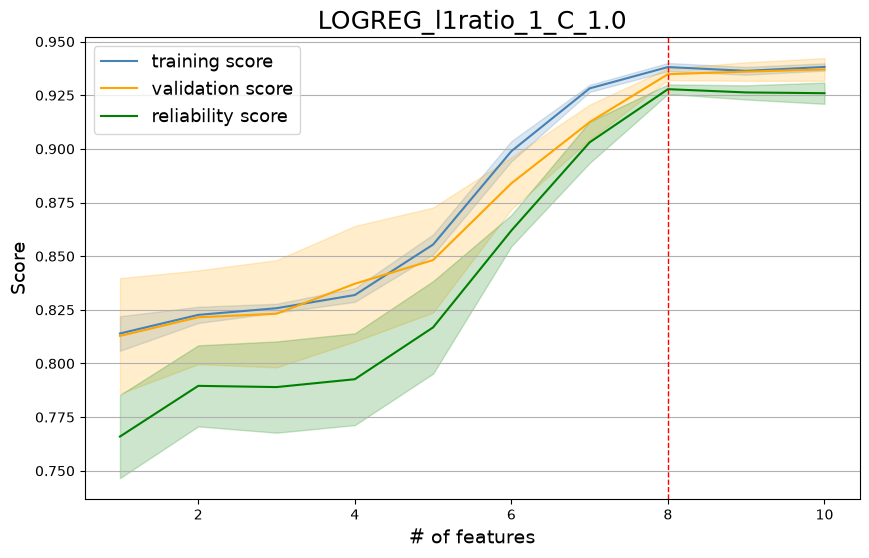

2026-10-01 17:07:06,682 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=8
2026-10-01 17:07:06,683 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['MinEStateIndex', 'VSA_EState5', 'HallKierAlpha', 'SMR_VSA1', 'fr_ether', 'VSA_EState2', 'fr_Imine', 'fr_C_O_noCOO']
2026-10-01 17:07:06,684 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.938 ± 0.002
2026-10-01 17:07:06,686 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.935 ± 0.003
2026-10-01 17:07:06,687 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.928 ± 0.002
2026-10-01 17:07:06,690 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 start: samples=535, features=46, k=3, n_jobs=12






-------------




COMBINATORIAL STAGE 1 - COARSE SEARCH


Stage 1: 100%|██████████| 175/175 [00:10<00:00, 15.91it/s]
2026-10-01 17:07:18,078 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 completed: kept_subsets=120


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se,Reliability_lower_bound
97,"[MaxAbsEStateIndex, NumHDonors, qed]",0.867121,0.842676,0.815662,0.002920,0.029524,0.029317,0.786346
104,"[TPSA, NumHDonors, MinEStateIndex]",0.842086,0.823756,0.801776,0.006191,0.016733,0.015498,0.786278
96,"[MaxAbsEStateIndex, NumHDonors, MinEStateIndex]",0.865867,0.829874,0.796086,0.003990,0.027328,0.022033,0.774053
70,"[EState_VSA9, MaxAbsEStateIndex, NumHDonors]",0.850448,0.813084,0.800843,0.009464,0.027987,0.030963,0.769880
93,"[MaxAbsEStateIndex, NumHDonors, PEOE_VSA8]",0.860590,0.826878,0.796902,0.007553,0.034000,0.033501,0.763401


2026-10-01 17:07:18,099 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 start: recurrent_features=['EState_VSA9' 'MaxAbsEStateIndex' 'MinEStateIndex' 'NumHDonors'
 'PEOE_VSA8' 'TPSA' 'qed'], subset_size=5, n_jobs=12


...

Stage 2: 100%|██████████| 119/119 [00:03<00:00, 36.97it/s]
2026-10-01 17:07:21,475 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 completed: kept_subsets=32
2026-10-01 17:07:21,477 - mlchem.ml.feature_selection.wrappers - INFO - # of Features: 5
2026-10-01 17:07:21,478 - mlchem.ml.feature_selection.wrappers - INFO - Best Features: [np.str_('EState_VSA9'), np.str_('MaxAbsEStateIndex'), np.str_('NumHDonors'), np.str_('PEOE_VSA8'), np.str_('qed')]
2026-10-01 17:07:21,480 - mlchem.ml.feature_selection.wrappers - INFO - Train Score: 0.866± 0.002
2026-10-01 17:07:21,481 - mlchem.ml.feature_selection.wrappers - INFO - CV Score: 0.844± 0.013
2026-10-01 17:07:21,485 - mlchem.ml.feature_selection.wrappers - INFO - Reliability Score: 0.834± 0.015


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se,Reliability_lower_bound
24,"[EState_VSA9, MaxAbsEStateIndex, NumHDonors, P...",0.865628,0.844107,0.833683,0.002416,0.012750,0.014863,0.818820
10,"[EState_VSA9, MaxAbsEStateIndex, NumHDonors, qed]",0.861226,0.846294,0.826695,0.004812,0.013113,0.011599,0.815096
29,"[MaxAbsEStateIndex, MinEStateIndex, NumHDonors...",0.869399,0.845328,0.818320,0.002873,0.019827,0.015203,0.803117
16,"[MaxAbsEStateIndex, NumHDonors, PEOE_VSA8, qed]",0.871505,0.844726,0.824872,0.003487,0.025525,0.027438,0.797434
22,"[EState_VSA9, MaxAbsEStateIndex, NumHDonors, T...",0.868812,0.832173,0.815988,0.003544,0.018376,0.020769,0.795219


2026-10-01 17:07:21,581 - mlchem.ml.feature_selection.wrappers - INFO - SFS start: samples=535, features=46, max_features=10, cv_iter=0, n_jobs=1



LOGREG_l1ratio_1_C_10.0




SFS: 100%|██████████| 10/10 [00:24<00:00,  2.43s/it]
2026-10-01 17:07:45,931 - mlchem.ml.feature_selection.wrappers - INFO - SFS completed: selected_features=10
2026-10-01 17:07:45,933 - mlchem.ml.feature_selection.wrappers - INFO - SFS parsimony: mode=uncertainty | reference_k*=10 | selected_k=7


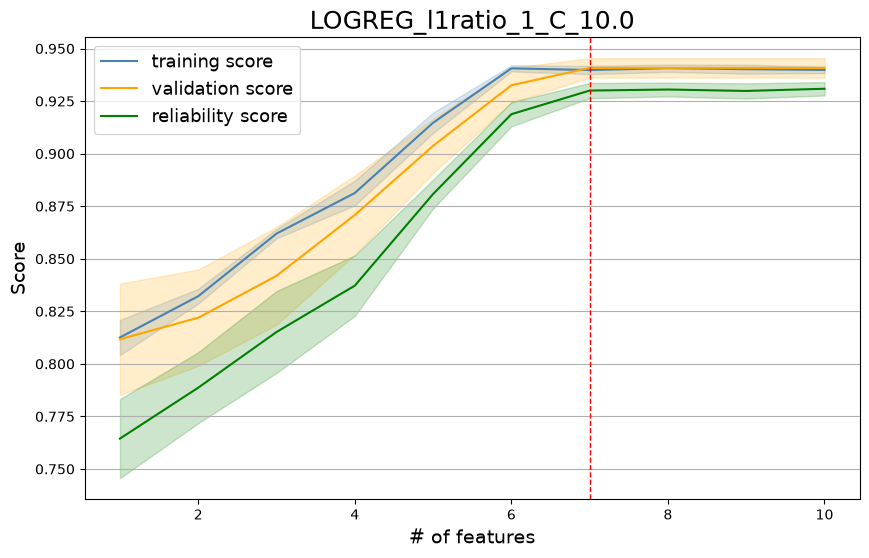

2026-10-01 17:07:46,286 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: number_of_features=7
2026-10-01 17:07:46,286 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: winner_subset=['MinEStateIndex', 'VSA_EState2', 'MaxAbsEStateIndex', 'SMR_VSA1', 'fr_ether', 'fr_Imine', 'fr_C_O_noCOO']
2026-10-01 17:07:46,292 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: train_score=0.940 ± 0.002
2026-10-01 17:07:46,294 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: cv_score=0.941 ± 0.005
2026-10-01 17:07:46,294 - mlchem.ml.feature_selection.wrappers - INFO - SFS summary: reliability_score=0.930 ± 0.004
2026-10-01 17:07:46,298 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 start: samples=535, features=46, k=3, n_jobs=12






-------------




COMBINATORIAL STAGE 1 - COARSE SEARCH


Stage 1: 100%|██████████| 175/175 [00:09<00:00, 18.80it/s]
2026-10-01 17:07:56,143 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 1 completed: kept_subsets=122


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se,Reliability_lower_bound
103,"[MaxAbsEStateIndex, NumHDonors, qed]",0.866213,0.845448,0.818061,0.003037,0.027164,0.026652,0.791409
106,"[TPSA, NumHDonors, MinEStateIndex]",0.844845,0.824792,0.803763,0.005387,0.015940,0.014793,0.788971
95,"[MaxAbsEStateIndex, NumHDonors, MinEStateIndex]",0.866352,0.829802,0.798862,0.004771,0.024484,0.020577,0.778285
76,"[EState_VSA9, MaxAbsEStateIndex, NumHDonors]",0.848901,0.815064,0.800262,0.009215,0.028923,0.030648,0.769613
97,"[MaxAbsEStateIndex, NumHDonors, PEOE_VSA8]",0.857105,0.823848,0.795137,0.006717,0.029691,0.029418,0.765719


2026-10-01 17:07:56,173 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 start: recurrent_features=['EState_VSA9' 'MaxAbsEStateIndex' 'MinEStateIndex' 'NumHDonors'
 'PEOE_VSA8' 'TPSA' 'qed'], subset_size=5, n_jobs=12


COMBINATORIAL STAGE 2 - FINE SEARCH


Stage 2: 100%|██████████| 119/119 [00:03<00:00, 35.59it/s]
2026-10-01 17:07:59,759 - mlchem.ml.feature_selection.wrappers - INFO - Combinatorial stage 2 completed: kept_subsets=29
2026-10-01 17:07:59,761 - mlchem.ml.feature_selection.wrappers - INFO - # of Features: 5
2026-10-01 17:07:59,764 - mlchem.ml.feature_selection.wrappers - INFO - Best Features: [np.str_('EState_VSA9'), np.str_('MaxAbsEStateIndex'), np.str_('NumHDonors'), np.str_('PEOE_VSA8'), np.str_('qed')]
2026-10-01 17:07:59,766 - mlchem.ml.feature_selection.wrappers - INFO - Train Score: 0.865± 0.002
2026-10-01 17:07:59,769 - mlchem.ml.feature_selection.wrappers - INFO - CV Score: 0.843± 0.013
2026-10-01 17:07:59,770 - mlchem.ml.feature_selection.wrappers - INFO - Reliability Score: 0.831± 0.014


,feature_subsets,training_score,cv_score,reliability_score,training_se,cv_se,reliability_se,Reliability_lower_bound
23,"[EState_VSA9, MaxAbsEStateIndex, NumHDonors, P...",0.864707,0.842821,0.830685,0.002314,0.012540,0.014059,0.816626
9,"[EState_VSA9, MaxAbsEStateIndex, NumHDonors, qed]",0.858755,0.840139,0.825413,0.003884,0.012826,0.011845,0.813567
28,"[MaxAbsEStateIndex, MinEStateIndex, NumHDonors...",0.870606,0.847315,0.819684,0.002967,0.018764,0.013591,0.806092
15,"[MaxAbsEStateIndex, NumHDonors, PEOE_VSA8, qed]",0.870074,0.848551,0.829139,0.002958,0.022295,0.023704,0.805435
22,"[EState_VSA9, MaxAbsEStateIndex, NumHDonors, T...",0.866365,0.837758,0.822527,0.002513,0.017957,0.019630,0.802897


In [28]:
SFS = wrappers.SequentialForwardSelection
metric = get_geometric_S

params = generate_cartesian_product([0,1],
                                    [1e-1,1e0,1e1])

for hyperparameter_list in params:
    estimator = LogisticRegression(l1_ratio=hyperparameter_list[0], C=hyperparameter_list[1], solver='liblinear', random_state=1)
    estimator_string = f'LOGREG_l1ratio_{hyperparameter_list[0]}_C_{hyperparameter_list[1]}'
    print('\n%s\n\n' % estimator_string)
    sfs = SFS(
        estimator=estimator,
        estimator_string=estimator_string,
        metric=metric,
        max_features=max_features,
        cv_iter=cv_iter,
        logic='greater',
        task_type='classification',
        log_level='INFO',
        cv_indices=cv_indices,
    )

    # test_set and y_test only useful for debugging purposes if log_level='DEBUG'
    sfs.fit(
        train_set=train_set_scaled,
        test_set=test_set_scaled,
        y_train=y_train,
        y_test=y_test,
    )
    features_best_sfs = sfs.find_best(parsimony_mode='uncertainty')['features']
    sfs.plot(title_size=18, title=estimator_string, best_feature=len(features_best_sfs))
    print('\n\n\n\n-------------\n\n\n\n')

    COMB = wrappers.CombinatorialSelection
    comb = COMB(estimator=estimator,metric=get_geometric_S,logic='greater',
                task_type='classification',cv_indices=cv_indices)

    print('COMBINATORIAL STAGE 1 - COARSE SEARCH')
    results_1 = comb.fit_stage_1(train_set=train_set_scaled,
                                y_train=y_train,
                                features=train_set_scaled.columns,
                                k=k,
                                training_threshold=training_threshold,
                                max_subsets=None,
                                ranking_target=y_train,
                                top_ranked_features=top_ranked_features,
                                cv_train_ratio=cv_train_ratio,
                                cv_iter=cv_iter,
                                n_jobs=n_jobs,)
    display(results_1.head())
    print('COMBINATORIAL STAGE 2 - FINE SEARCH')
    results_2 = comb.fit_stage_2(top_n_subsets=top_n_subsets,cv_iter=cv_iter,n_jobs=-1)
    display(results_2.head())

    fitted_estimator_sfs = estimator.fit(train_set_scaled[features_best_sfs], y_train)
    joblib.dump(fitted_estimator_sfs, f'../data/{estimator_string}_SFS_estimator')
    joblib.dump(features_best_sfs, f'../data/{estimator_string}_SFS_cols')

    if results_2.empty:
        # No subset survived the stage-2 cv_train_ratio/training_threshold filters for this estimator
        print(f'No combinatorial subsets passed the stage-2 filters for {estimator_string}; skipping COMB save.')
    else:
        features_best_comb = results_2['feature_subsets'].values[0]
        fitted_estimator_comb = estimator.fit(train_set_scaled[features_best_comb], y_train)
        joblib.dump(fitted_estimator_comb, f'../data/{estimator_string}_COMB_estimator')
        joblib.dump(features_best_comb, f'../data/{estimator_string}_COMB_cols')